In [121]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from tailwind_colors import TAILWIND_COLORS_HEX
from scipy.interpolate import CubicSpline
import json, io

/var/folders/51/h63s2_h92rzgrxywvfh_pzdc0000gn/T/ipykernel_82053/1523199753.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = df.astype({'StartDate': 'datetime64[ns]'})


,Index,StartDate,Color,Growth,ChangePoint,Next Phase
0,0,2019-07-01,#fde047,1,Enter,UX & Devops
1,1,2020-02-01,#5eead4,2,First Level Up,Backend Engineer
2,2,2021-06-01,#e5e7eb,7,Reorganizing,Backend Engineer
3,2,2021-06-01,#e5e7eb,7,Reorganizing,Backend Engineer
4,3,2022-01-01,#60a5fa,10,Start DataScience,DataScientist
5,4,2022-07-01,NaN,14,Exit,NaN


<>:26: SyntaxWarning: "is not" with a literal. Did you mean "!="?
<>:26: SyntaxWarning: "is not" with a literal. Did you mean "!="?
/var/folders/51/h63s2_h92rzgrxywvfh_pzdc0000gn/T/ipykernel_82053/1654067310.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = df.astype({'StartDate': 'datetime64[ns]'})


,Index,StartDate,Color,Growth,ChangePoint,NextPhase
0,0,2019-07-01,#8ECDDD,1,Joined Blockchain Team,UX & Devops
1,1,2020-02-01,#22668D,2,First Level Up,
2,2,2022-11-01,#22668D,6,LaunchedHLF PrivatePreview,
3,3,2021-08-01,#22668D,8,Financial Cloud Team,Backend Developer & System Architect
4,4,2022-01-01,#FFCC70,9,FarmBeats Team as SD2,DataScientist
5,5,2022-07-01,#FFCC70,14,Left,


/var/folders/51/h63s2_h92rzgrxywvfh_pzdc0000gn/T/ipykernel_82053/1654067310.py:26: SyntaxWarning: "is not" with a literal. Did you mean "!="?
  if df['NextPhase'][i] is not "":
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


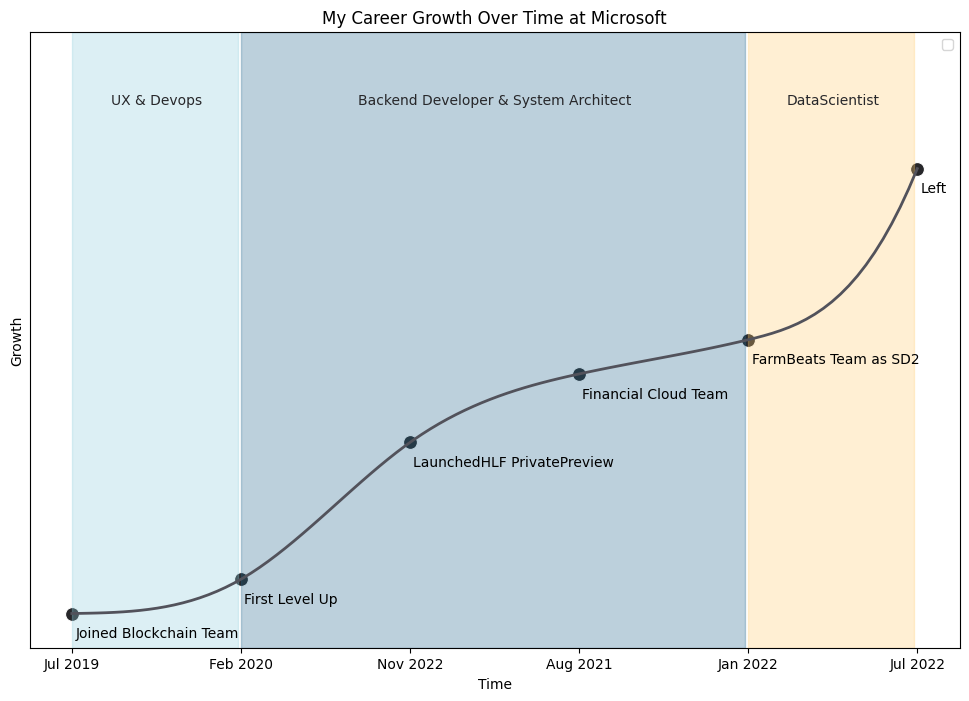

In [142]:
# creating data
df = pd.read_csv('data.csv')
df = df.astype({'StartDate': 'datetime64[ns]'})
df.fillna('', inplace=True)
display(df)


x = df['Index']
y = df['Growth']
# print(x, y)
cs = CubicSpline([-1] + list(x) + [len(x)], [0] + list(y) + [40])
xs = np.linspace(np.min(x), np.max(x), 100)
ys = cs(xs)
# print(xs, ys)

fig, ax = plt.subplots(figsize=(12, 8))
sns.lineplot(x=xs, y=ys, linewidth=2, color=TAILWIND_COLORS_HEX.ZINC_600, ax=ax)
sns.scatterplot(x=x, y=y, ax=ax, s=100, color=TAILWIND_COLORS_HEX.ZINC_800)


# Plot background colors
prev_stint = 0
for i in range(len(df)):
    ax.text(df['Index'][i]+.02, df['Growth'][i]-0.7, str(df['ChangePoint'][i]))
    if i < len(df) - 1: 
        if df['NextPhase'][i] is not "":
            plt.axvspan(df['Index'][prev_stint], df['Index'][i+1]-0.02, color=df['Color'][i], alpha=0.3)
            center_x = (df['Index'][prev_stint] + df['Index'][i+1]) / 2
            center_y = 16
            ax.text(center_x, center_y, str(df['NextPhase'][i]), ha='center', va='center', fontsize=10, color=TAILWIND_COLORS_HEX.ZINC_800, fontfamily='sans-serif')
            prev_stint = i + 1


# # Plot the spline
# plt.plot(x_smooth, y_smooth, linestyle='-', marker='o', markersize=5, color='blue', label='Interpolated Growth')

# Customize the chart
plt.title("My Career Growth Over Time at Microsoft")

plt.xticks(df['Index'], labels=[dt.strftime("%b %Y") for dt in df['StartDate']])
plt.yticks([])

plt.xlabel("Time")
plt.ylabel("Growth")
plt.ylim(0, 18)
plt.legend()
plt.show()